
ARTIFICIAL NEURAL NETWORK FROM SCRATCH

This implementation includes:
✓ Multiple activation functions (Sigmoid, ReLU, Tanh)
✓ Forward propagation
✓ Backward propagation (Backpropagation)
✓ Gradient descent optimization
✓ Flexible architecture (any number of layers)
✓ Training and prediction methods
EXAMPLE: Solving XOR Problem

XOR Truth Table:
Input | Output
------|-------
[0 0] | 0
[0 1] | 1
[1 0] | 1
[1 1] | 0

Training Neural Network...
Epoch 0/5000 - Loss: 0.7760 - Accuracy: 0.5000
Epoch 100/5000 - Loss: 0.6699 - Accuracy: 0.5000
Epoch 200/5000 - Loss: 0.6115 - Accuracy: 0.5000
Epoch 300/5000 - Loss: 0.5174 - Accuracy: 0.5000
Epoch 400/5000 - Loss: 0.4403 - Accuracy: 0.5000
Epoch 500/5000 - Loss: 0.3581 - Accuracy: 1.0000
Epoch 600/5000 - Loss: 0.2301 - Accuracy: 1.0000
Epoch 700/5000 - Loss: 0.1445 - Accuracy: 1.0000
Epoch 800/5000 - Loss: 0.0985 - Accuracy: 1.0000
Epoch 900/5000 - Loss: 0.0719 - Accuracy: 1.0000
Epoch 1000/5000 - Loss: 0.0552 - Accuracy: 1.0000
Epoch 1100/5000 

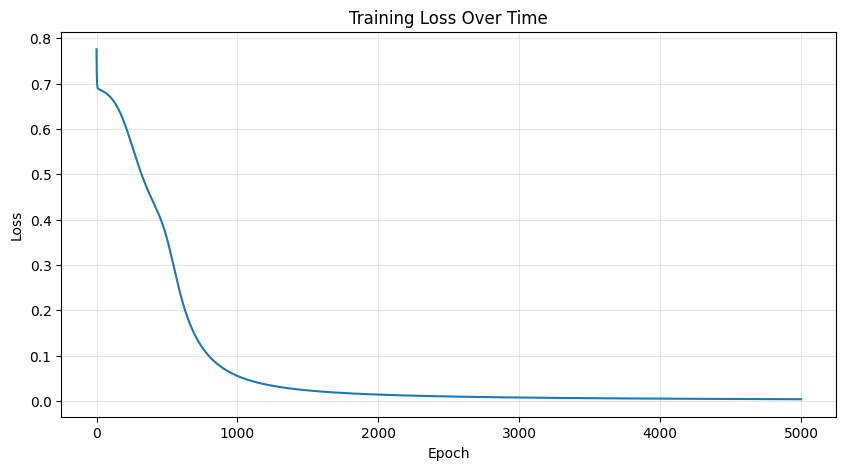


EXAMPLE: Binary Classification

Training on 200 samples...
Epoch 0/2000 - Loss: 0.5671 - Accuracy: 1.0000
Epoch 100/2000 - Loss: 0.0126 - Accuracy: 1.0000
Epoch 200/2000 - Loss: 0.0059 - Accuracy: 1.0000
Epoch 300/2000 - Loss: 0.0038 - Accuracy: 1.0000
Epoch 400/2000 - Loss: 0.0028 - Accuracy: 1.0000
Epoch 500/2000 - Loss: 0.0022 - Accuracy: 1.0000
Epoch 600/2000 - Loss: 0.0018 - Accuracy: 1.0000
Epoch 700/2000 - Loss: 0.0015 - Accuracy: 1.0000
Epoch 800/2000 - Loss: 0.0013 - Accuracy: 1.0000
Epoch 900/2000 - Loss: 0.0012 - Accuracy: 1.0000
Epoch 1000/2000 - Loss: 0.0010 - Accuracy: 1.0000
Epoch 1100/2000 - Loss: 0.0009 - Accuracy: 1.0000
Epoch 1200/2000 - Loss: 0.0008 - Accuracy: 1.0000
Epoch 1300/2000 - Loss: 0.0008 - Accuracy: 1.0000
Epoch 1400/2000 - Loss: 0.0007 - Accuracy: 1.0000
Epoch 1500/2000 - Loss: 0.0007 - Accuracy: 1.0000
Epoch 1600/2000 - Loss: 0.0006 - Accuracy: 1.0000
Epoch 1700/2000 - Loss: 0.0006 - Accuracy: 1.0000
Epoch 1800/2000 - Loss: 0.0005 - Accuracy: 1.0000
Ep

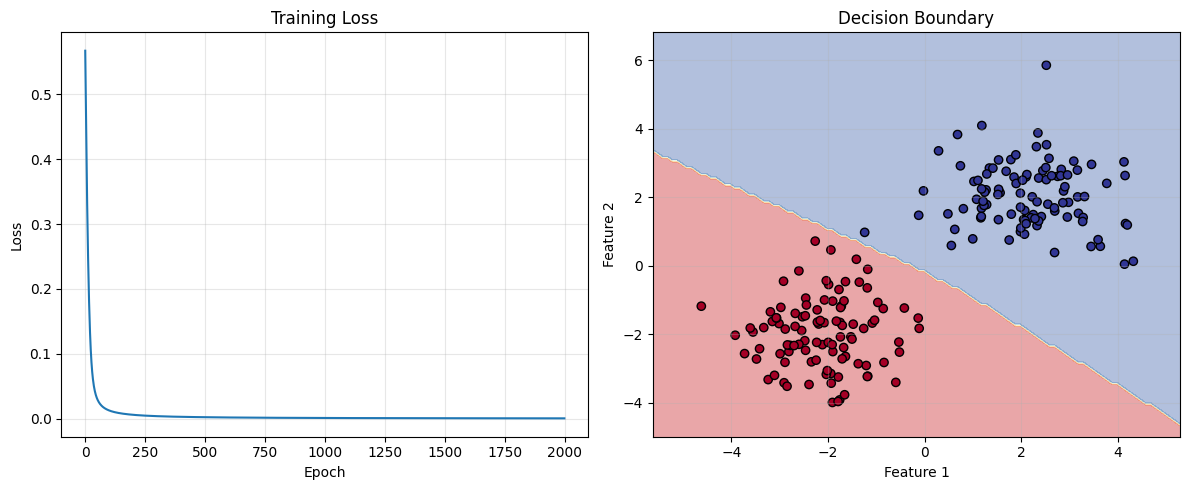


Tutorial Complete!

Key Concepts Covered:
1. Neural network architecture
2. Activation functions
3. Forward propagation
4. Loss computation
5. Backpropagation
6. Gradient descent
7. Training and prediction


In [1]:
"""
Building Artificial Neural Networks from Scratch in Python
===========================================================
A complete implementation with no deep learning libraries
"""

import numpy as np
import matplotlib.pyplot as plt

# 1. ACTIVATION FUNCTIONS

class ActivationFunctions:    
    @staticmethod
    def sigmoid(x):
        """Sigmoid activation: outputs values between 0 and 1"""
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    
    @staticmethod
    def sigmoid_derivative(x):
        """Derivative of sigmoid"""
        s = ActivationFunctions.sigmoid(x)
        return s * (1 - s)
    
    @staticmethod
    def relu(x):
        """ReLU activation: max(0, x)"""
        return np.maximum(0, x)
    
    @staticmethod
    def relu_derivative(x):
        """Derivative of ReLU"""
        return (x > 0).astype(float)
    
    @staticmethod
    def tanh(x):
        """Tanh activation: outputs between -1 and 1"""
        return np.tanh(x)
    
    @staticmethod
    def tanh_derivative(x):
        """Derivative of tanh"""
        return 1 - np.tanh(x) ** 2

# 2. NEURAL NETWORK CLASS
class NeuralNetwork:
    """
    A simple feedforward neural network built from scratch
    
    Parameters:
    -----------
    layer_sizes : list
        Number of neurons in each layer (including input and output)
        Example: [2, 4, 3, 1] means:
        - Input layer: 2 neurons
        - Hidden layer 1: 4 neurons
        - Hidden layer 2: 3 neurons
        - Output layer: 1 neuron
    
    learning_rate : float
        Learning rate for gradient descent
    
    activation : str
        Activation function ('sigmoid', 'relu', 'tanh')
    """
    
    def __init__(self, layer_sizes, learning_rate=0.01, activation='sigmoid'):
        self.layer_sizes = layer_sizes
        self.learning_rate = learning_rate
        self.num_layers = len(layer_sizes)
        
        # Select activation function
        if activation == 'sigmoid':
            self.activation = ActivationFunctions.sigmoid
            self.activation_derivative = ActivationFunctions.sigmoid_derivative
        elif activation == 'relu':
            self.activation = ActivationFunctions.relu
            self.activation_derivative = ActivationFunctions.relu_derivative
        elif activation == 'tanh':
            self.activation = ActivationFunctions.tanh
            self.activation_derivative = ActivationFunctions.tanh_derivative
        
        # Initialize weights and biases
        self.weights = []
        self.biases = []
        
        for i in range(self.num_layers - 1):
            # Xavier/He initialization for better convergence
            w = np.random.randn(layer_sizes[i], layer_sizes[i + 1]) * np.sqrt(2.0 / layer_sizes[i])
            b = np.zeros((1, layer_sizes[i + 1]))
            self.weights.append(w)
            self.biases.append(b)
    
    def forward_propagation(self, X):
        """
        Forward pass through the network
        
        Parameters:
        -----------
        X : numpy array
            Input data (m samples, n features)
        
        Returns:
        --------
        activations : list
            Activations at each layer
        z_values : list
            Pre-activation values at each layer
        """
        activations = [X]
        z_values = []
        
        for i in range(self.num_layers - 1):
            # Linear transformation: Z = XW + b
            z = np.dot(activations[-1], self.weights[i]) + self.biases[i]
            z_values.append(z)
            
            # Apply activation function
            if i == self.num_layers - 2:  # Output layer
                # Use sigmoid for output (binary classification)
                a = ActivationFunctions.sigmoid(z)
            else:  # Hidden layers
                a = self.activation(z)
            
            activations.append(a)
        
        return activations, z_values
    
    def backward_propagation(self, X, y, activations, z_values):
        """
        Backward pass to compute gradients
        
        Parameters:
        -----------
        X : numpy array
            Input data
        y : numpy array
            True labels
        activations : list
            Activations from forward pass
        z_values : list
            Pre-activation values from forward pass
        
        Returns:
        --------
        weight_gradients : list
            Gradients for weights
        bias_gradients : list
            Gradients for biases
        """
        m = X.shape[0]  # Number of samples
        
        weight_gradients = []
        bias_gradients = []
        
        # Output layer error
        delta = activations[-1] - y
        
        # Backpropagate through layers
        for i in range(self.num_layers - 2, -1, -1):
            # Compute gradients
            dW = np.dot(activations[i].T, delta) / m
            db = np.sum(delta, axis=0, keepdims=True) / m
            
            weight_gradients.insert(0, dW)
            bias_gradients.insert(0, db)
            
            if i > 0:  # Not the input layer
                # Propagate error backwards
                delta = np.dot(delta, self.weights[i].T) * self.activation_derivative(z_values[i - 1])
        
        return weight_gradients, bias_gradients
    
    def update_parameters(self, weight_gradients, bias_gradients):
        """Update weights and biases using gradient descent"""
        for i in range(len(self.weights)):
            self.weights[i] -= self.learning_rate * weight_gradients[i]
            self.biases[i] -= self.learning_rate * bias_gradients[i]
    
    def compute_loss(self, y_true, y_pred):
        """Binary cross-entropy loss"""
        m = y_true.shape[0]
        epsilon = 1e-15  # To avoid log(0)
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        return loss
    
    def train(self, X, y, epochs=1000, verbose=True):
        """
        Train the neural network
        
        Parameters:
        -----------
        X : numpy array
            Training data
        y : numpy array
            Training labels
        epochs : int
            Number of training iterations
        verbose : bool
            Print training progress
        
        Returns:
        --------
        losses : list
            Loss values during training
        """
        losses = []
        
        for epoch in range(epochs):
            # Forward propagation
            activations, z_values = self.forward_propagation(X)
            
            # Compute loss
            loss = self.compute_loss(y, activations[-1])
            losses.append(loss)
            
            # Backward propagation
            weight_gradients, bias_gradients = self.backward_propagation(X, y, activations, z_values)
            
            # Update parameters
            self.update_parameters(weight_gradients, bias_gradients)
            
            # Print progress
            if verbose and (epoch % 100 == 0 or epoch == epochs - 1):
                accuracy = self.compute_accuracy(X, y)
                print(f"Epoch {epoch}/{epochs} - Loss: {loss:.4f} - Accuracy: {accuracy:.4f}")
        
        return losses
    
    def predict(self, X):
        """Make predictions"""
        activations, _ = self.forward_propagation(X)
        return (activations[-1] > 0.5).astype(int)
    
    def predict_proba(self, X):
        """Get probability predictions"""
        activations, _ = self.forward_propagation(X)
        return activations[-1]
    
    def compute_accuracy(self, X, y):
        """Compute accuracy"""
        predictions = self.predict(X)
        return np.mean(predictions == y)

# 3. EXAMPLE: XOR PROBLEM
def example_xor_problem():
    """
    Solve the classic XOR problem
    XOR is not linearly separable, so we need a neural network
    """
    print("=" * 60)
    print("EXAMPLE: Solving XOR Problem")
    print("=" * 60)
    
    # XOR dataset
    X = np.array([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]])
    
    y = np.array([[0],
                  [1],
                  [1],
                  [0]])
    
    print("\nXOR Truth Table:")
    print("Input | Output")
    print("------|-------")
    for i in range(len(X)):
        print(f"{X[i]} | {y[i][0]}")
    
    # Create neural network
    # Architecture: 2 inputs -> 4 hidden neurons -> 1 output
    nn = NeuralNetwork(layer_sizes=[2, 4, 1], learning_rate=0.5, activation='sigmoid')
    
    # Train the network
    print("\n" + "=" * 60)
    print("Training Neural Network...")
    print("=" * 60)
    losses = nn.train(X, y, epochs=5000, verbose=True)
    
    # Test predictions
    print("\n" + "=" * 60)
    print("Final Predictions:")
    print("=" * 60)
    predictions = nn.predict(X)
    probabilities = nn.predict_proba(X)
    
    print("Input | True | Predicted | Probability")
    print("------|------|-----------|------------")
    for i in range(len(X)):
        print(f"{X[i]} | {y[i][0]:^4} | {predictions[i][0]:^9} | {probabilities[i][0]:.4f}")
    
    # Plot training loss
    plt.figure(figsize=(10, 5))
    plt.plot(losses)
    plt.title('Training Loss Over Time')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)
    plt.show()

# 4. EXAMPLE: BINARY CLASSIFICATION
def example_binary_classification():
    """
    Binary classification with synthetic data
    """
    print("\n" + "=" * 60)
    print("EXAMPLE: Binary Classification")
    print("=" * 60)
    
    # Generate synthetic data
    np.random.seed(42)
    
    # Class 0: centered at (-2, -2)
    X0 = np.random.randn(100, 2) + np.array([-2, -2])
    y0 = np.zeros((100, 1))
    
    # Class 1: centered at (2, 2)
    X1 = np.random.randn(100, 2) + np.array([2, 2])
    y1 = np.ones((100, 1))
    
    # Combine data
    X = np.vstack([X0, X1])
    y = np.vstack([y0, y1])
    
    # Shuffle
    indices = np.random.permutation(len(X))
    X = X[indices]
    y = y[indices]
    
    # Create and train network
    nn = NeuralNetwork(layer_sizes=[2, 8, 4, 1], learning_rate=0.1, activation='relu')
    
    print("\nTraining on 200 samples...")
    losses = nn.train(X, y, epochs=2000, verbose=True)
    
    # Final accuracy
    accuracy = nn.compute_accuracy(X, y)
    print(f"\nFinal Training Accuracy: {accuracy:.4f}")
    
    # Visualize decision boundary
    plt.figure(figsize=(12, 5))
    
    # Plot 1: Training loss
    plt.subplot(1, 2, 1)
    plt.plot(losses)
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Decision boundary
    plt.subplot(1, 2, 2)
    h = 0.1
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = nn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
    plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap='RdYlBu', edgecolors='black')
    plt.title('Decision Boundary')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# 5. MAIN EXECUTION
if __name__ == "__main__":
    print("\n" + "=" * 60)
    print("ARTIFICIAL NEURAL NETWORK FROM SCRATCH")
    print("=" * 60)
    print("\nThis implementation includes:")
    print("✓ Multiple activation functions (Sigmoid, ReLU, Tanh)")
    print("✓ Forward propagation")
    print("✓ Backward propagation (Backpropagation)")
    print("✓ Gradient descent optimization")
    print("✓ Flexible architecture (any number of layers)")
    print("✓ Training and prediction methods")
    
    # Run examples
    example_xor_problem()
    example_binary_classification()
    
    print("\n" + "=" * 60)
    print("Tutorial Complete!")
    print("=" * 60)
    print("\nKey Concepts Covered:")
    print("1. Neural network architecture")
    print("2. Activation functions")
    print("3. Forward propagation")
    print("4. Loss computation")
    print("5. Backpropagation")
    print("6. Gradient descent")
    print("7. Training and prediction")